In [1]:
import seaborn as sns
import plotly.io as pio
import matplotlib.pyplot as plt
import plotly.express as px
import os
import pandas as pd
from pandas import DataFrame
import sys
sys.path.append('../')

from aztec_gddt.experiment import custom_run
from aztec_gddt.default_params import *
from aztec_gddt.types import *

pio.renderers.default = "png"

In [2]:
# Manual Param Setting 
# Params_to_modify consists of a dictionary with certain parameter choices. They can be changed for each run through the following argument. 
# Params can be seen in default_params.py: DEFAULT_PARAMS = ModelParams
params_to_modify = {}
params_to_modify = {'OVERHEAD_MANA_PER_TX': [32000], 'RELATIVE_TARGET_MANA_PER_BLOCK': [0.6], 'market_price_eth': [2500], 'SIGNATURE_SKIP_PROBABILITY': [0.50], 'GWEI_PER_L1GAS_MEAN': [50], 'AVERAGE_TX_COUNT_PER_SLOT': [5]}


# N_timesteps lets us vary the simulation timesteps we want to run
N_timesteps = 100

# N_samples defines the number of simulation runs we want
N_samples = 1

#sim_df saves the run to a dataframe, from which we can plot any state measurements or metrics
sim_df = custom_run(N_timesteps=N_timesteps,
                    N_samples=N_samples, params_to_modify=params_to_modify)

In [3]:
print(sim_df)

     index  timestep  l1_blocks_passed  delta_l1_blocks  l2_blocks_passed  \
0        0         0                 0                0                 0   
1        7         1                 1                1                 1   
2       14         2                 2                1                 1   
3       21         3                 3                1                 1   
4       28         4                 4                1                 2   
..     ...       ...               ...              ...               ...   
96     672        96                96                1                32   
97     679        97                97                1                33   
98     686        98                98                1                33   
99     693        99                99                1                33   
100    700       100               100                1                34   

                                                agents validator_set  \
0  

In [4]:
sim_df.columns

Index(['index', 'timestep', 'l1_blocks_passed', 'delta_l1_blocks',
       'l2_blocks_passed', 'agents', 'validator_set', 'current_epoch',
       'last_epoch', 'last_reward_time_in_l1', 'last_reward',
       'market_price_juice_per_gwei', 'market_price_l1_gas',
       'market_price_l1_blobgas', 'oracle_price_juice_per_gwei',
       'oracle_price_l1_gas', 'oracle_price_l1_blobgas',
       'update_time_oracle_price_juice_per_gwei',
       'update_time_oracle_price_l1_gas',
       'update_time_oracle_price_l1_blobgas', 'oracle_proving_cost',
       'congestion_multiplier', 'excess_mana', 'base_fee', 'cumm_empty_blocks',
       'cumm_unproven_epochs', 'cumm_dropped_tx', 'cumm_excl_tx',
       'cumm_total_tx', 'cumm_resolved_epochs', 'cumm_finalized_epochs',
       'cumm_mana_used_on_finalized_blocks', 'cumm_finalized_blocks',
       'cumm_blocks_with_collected_signatures',
       'cumm_blocks_with_enough_signatures', 'slash_count', 'slash_amount',
       'simulation', 'subset', 'run', 'labe

In [5]:
# Let's grab the final row of our state measurements and examine. 
sim_df.iloc[-1]

index                                                            700
timestep                                                         100
l1_blocks_passed                                                 100
delta_l1_blocks                                                    1
l2_blocks_passed                                                  34
                                              ...                   
PROVER_QUOTE_LOWER_BOUND                                         0.1
PROVER_QUOTE_RANGE                                               0.8
PROVER_QUOTE_MODE                                                0.3
JUICE_PER_GWEI_SCENARIO     JuiceGweiExchangeRateScenario.Stochastic
market_price_eth                                                2500
Name: 100, Length: 94, dtype: object

In [6]:
# Lets grab all rows except for the final one and decide what to look for 
sim_df.head(-1)

,index,timestep,l1_blocks_passed,delta_l1_blocks,l2_blocks_passed,agents,validator_set,current_epoch,last_epoch,last_reward_time_in_l1,...,GWEI_PER_L1BLOBGAS_COV,SEQUENCER_L1_GAS_PRICE_THRESHOLD_E,TOTAL_MANA_MULTIPLIER_E,SIGNATURE_SKIP_PROBABILITY,MAX_VALIDATORS_TO_SLASH,PROVER_QUOTE_LOWER_BOUND,PROVER_QUOTE_RANGE,PROVER_QUOTE_MODE,JUICE_PER_GWEI_SCENARIO,market_price_eth
0,0,0,0,0,0,"{'prover': Agent(uuid='prover', stake=1000, sc...",{},"Epoch(init_time_in_l1=-999, validators=[], slo...","Epoch(init_time_in_l1=-999, validators=[], slo...",0,...,0.05,NaN,1.0,0.5,0.0,0.1,0.8,0.3,JuiceGweiExchangeRateScenario.Stochastic,2500
1,7,1,1,1,1,"{'prover': Agent(uuid='prover', stake=1000, sc...",{},"Epoch(init_time_in_l1=1, validators=['253', '1...","Epoch(init_time_in_l1=-999, validators=[], slo...",0,...,0.05,NaN,1.0,0.5,0.0,0.1,0.8,0.3,JuiceGweiExchangeRateScenario.Stochastic,2500
2,14,2,2,1,1,"{'prover': Agent(uuid='prover', stake=1000, sc...",{},"Epoch(init_time_in_l1=1, validators=['253', '1...","Epoch(init_time_in_l1=-999, validators=[], slo...",0,...,0.05,NaN,1.0,0.5,0.0,0.1,0.8,0.3,JuiceGweiExchangeRateScenario.Stochastic,2500
3,21,3,3,1,1,"{'prover': Agent(uuid='prover', stake=1000, sc...",{},"Epoch(init_time_in_l1=1, validators=['253', '1...","Epoch(init_time_in_l1=-999, validators=[], slo...",0,...,0.05,NaN,1.0,0.5,0.0,0.1,0.8,0.3,JuiceGweiExchangeRateScenario.Stochastic,2500
4,28,4,4,1,2,"{'prover': Agent(uuid='prover', stake=1000, sc...",{},"Epoch(init_time_in_l1=1, validators=['253', '1...","Epoch(init_time_in_l1=-999, validators=[], slo...",0,...,0.05,NaN,1.0,0.5,0.0,0.1,0.8,0.3,JuiceGweiExchangeRateScenario.Stochastic,2500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,665,95,95,1,32,"{'prover': Agent(uuid='prover', stake=1000, sc...",{},"Epoch(init_time_in_l1=1, validators=['253', '1...","Epoch(init_time_in_l1=-999, validators=[], slo...",0,...,0.05,NaN,1.0,0.5,0.0,0.1,0.8,0.3,JuiceGweiExchangeRateScenario.Stochastic,2500
96,672,96,96,1,32,"{'prover': Agent(uuid='prover', stake=1000, sc...",{},"Epoch(init_time_in_l1=1, validators=['253', '1...","Epoch(init_time_in_l1=-999, validators=[], slo...",0,...,0.05,NaN,1.0,0.5,0.0,0.1,0.8,0.3,JuiceGweiExchangeRateScenario.Stochastic,2500
97,679,97,97,1,33,"{'prover': Agent(uuid='prover', stake=1000, sc...",{},"Epoch(init_time_in_l1=97, validators=['2', '12...","Epoch(init_time_in_l1=1, validators=['253', '1...",0,...,0.05,NaN,1.0,0.5,0.0,0.1,0.8,0.3,JuiceGweiExchangeRateScenario.Stochastic,2500
98,686,98,98,1,33,"{'prover': Agent(uuid='prover', stake=1000, sc...",{},"Epoch(init_time_in_l1=97, validators=['2', '12...","Epoch(init_time_in_l1=1, validators=['253', '1...",0,...,0.05,NaN,1.0,0.5,0.0,0.1,0.8,0.3,JuiceGweiExchangeRateScenario.Stochastic,2500


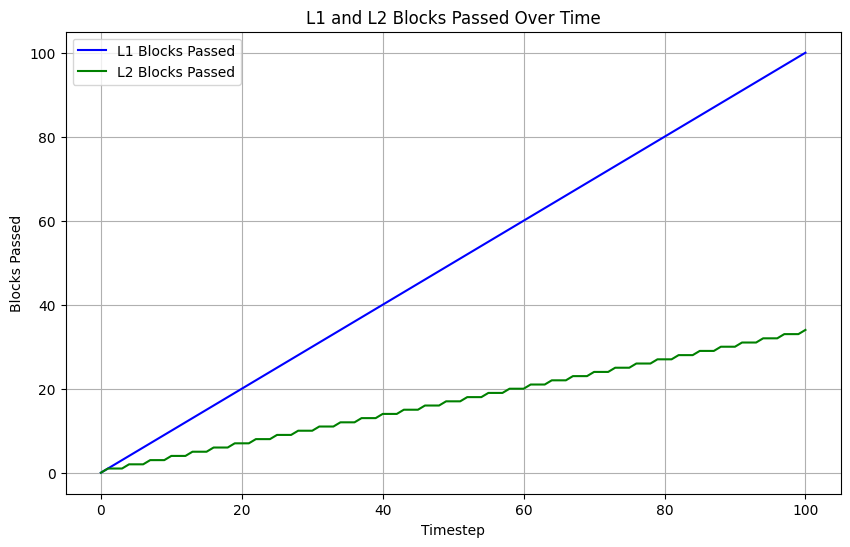

In [7]:
# Time series plot
plt.figure(figsize=(10, 6))
plt.plot(sim_df['timestep'], sim_df['l1_blocks_passed'], label='L1 Blocks Passed', color='blue')
plt.plot(sim_df['timestep'], sim_df['l2_blocks_passed'], label='L2 Blocks Passed', color='green')
plt.title('L1 and L2 Blocks Passed Over Time')
plt.xlabel('Timestep')
plt.ylabel('Blocks Passed')
plt.legend()
plt.grid(True)
plt.show()


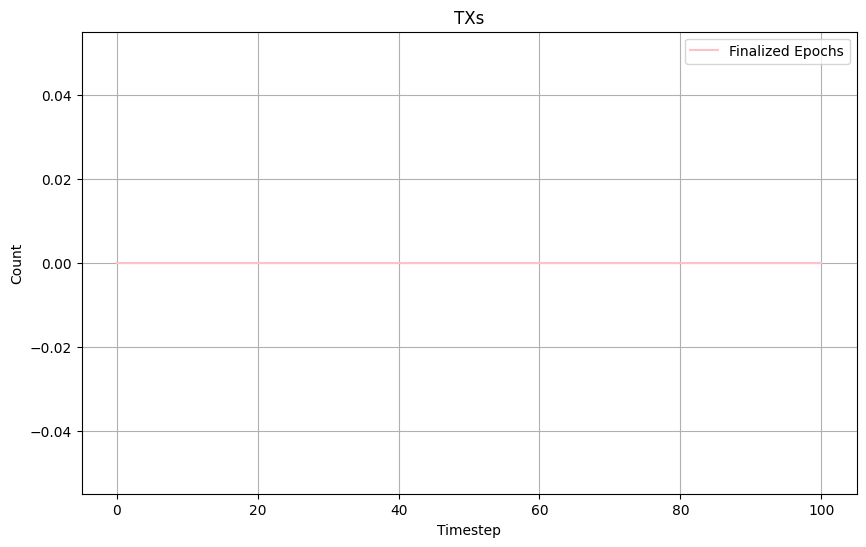

In [20]:
# Time series plot
plt.figure(figsize=(10, 6))
plt.plot(sim_df['timestep'], sim_df['cumm_finalized_epochs'], label='Finalized Epochs', color='pink')
plt.title('TXs')
plt.xlabel('Timestep')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.show()

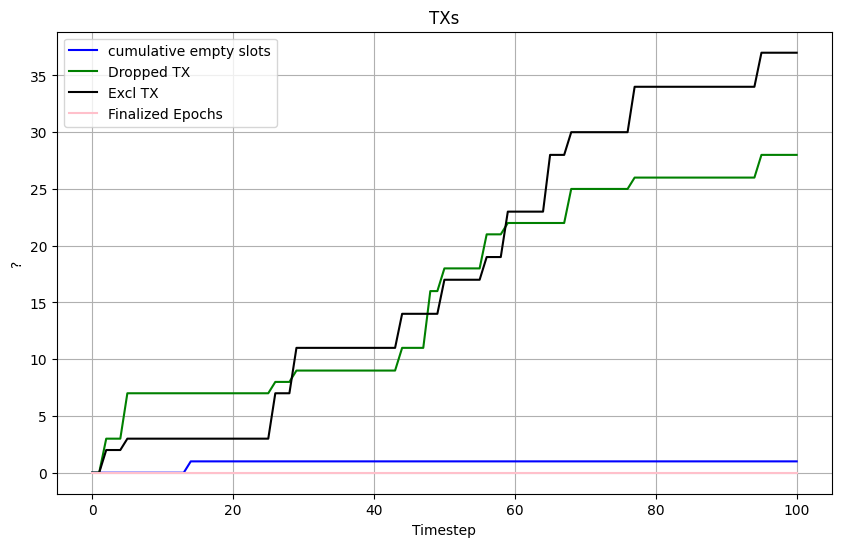

In [9]:
# Time series plot
plt.figure(figsize=(10, 6))
plt.plot(sim_df['timestep'], sim_df['cumm_empty_blocks'], label='cumulative empty slots', color='blue')
plt.plot(sim_df['timestep'], sim_df['cumm_dropped_tx'], label='Dropped TX', color='green')
plt.plot(sim_df['timestep'], sim_df['cumm_excl_tx'], label='Excl TX', color='black')
plt.plot(sim_df['timestep'], sim_df['cumm_finalized_epochs'], label='Finalized Epochs', color='pink')
plt.title('TXs')
plt.xlabel('Timestep')
plt.ylabel('?')
plt.legend()
plt.grid(True)
plt.show()


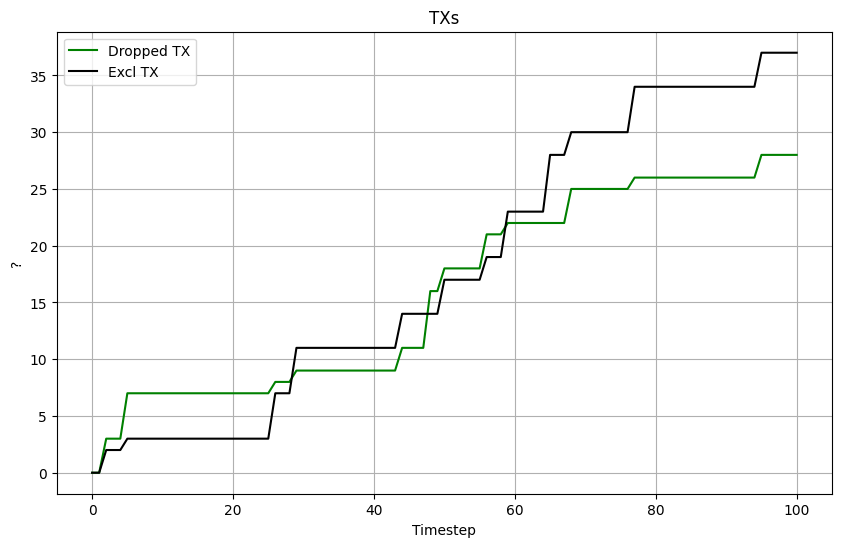

In [10]:
# Time series plot
plt.figure(figsize=(10, 6))
plt.plot(sim_df['timestep'], sim_df['cumm_dropped_tx'], label='Dropped TX', color='green')
plt.plot(sim_df['timestep'], sim_df['cumm_excl_tx'], label='Excl TX', color='black')
plt.title('TXs')
plt.xlabel('Timestep')
plt.ylabel('?')
plt.legend()
plt.grid(True)
plt.show()

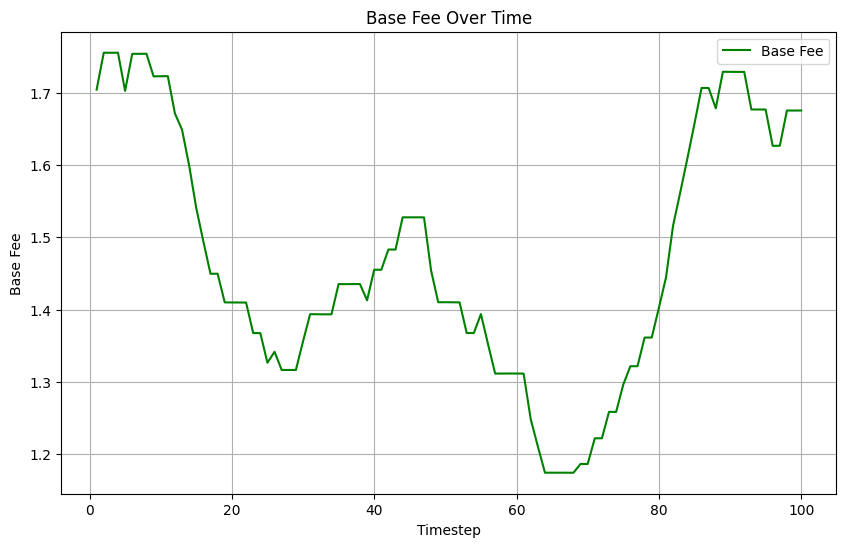

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(sim_df['timestep'], sim_df['base_fee'], label='Base Fee', color='green')
plt.title('Base Fee Over Time')
plt.xlabel('Timestep')
plt.ylabel('Base Fee')
plt.legend()
plt.grid(True)
plt.show()

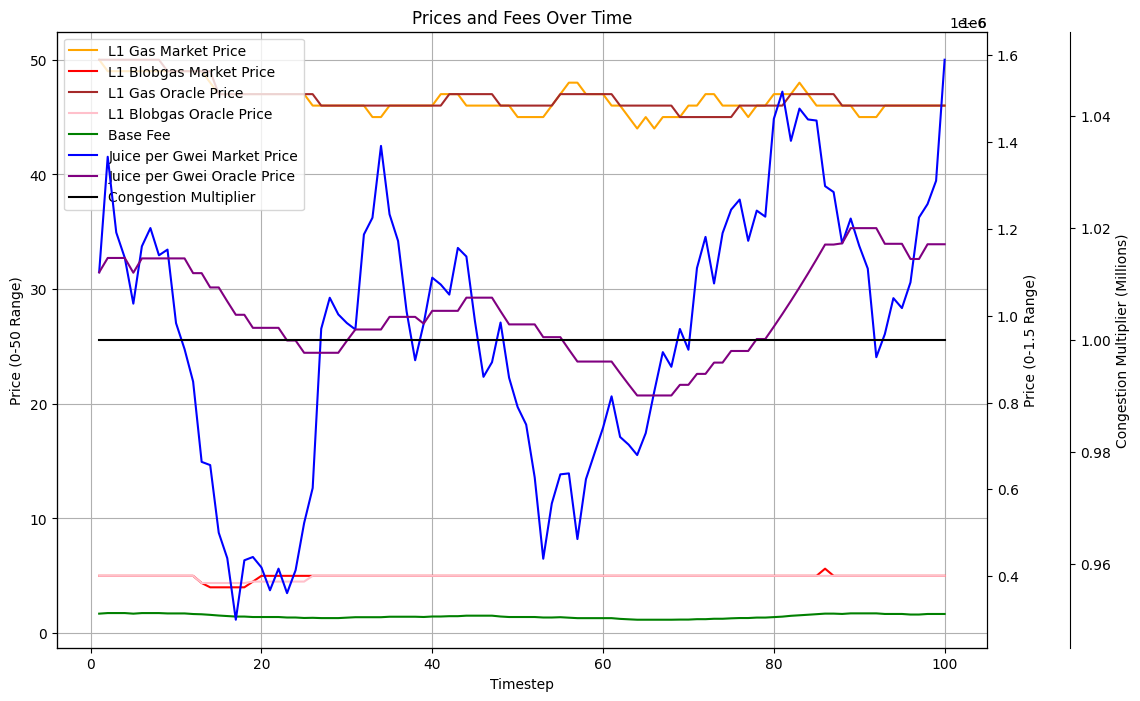

In [12]:
# 3 axis in one, not a beaut but works 

# Create a figure and the first subplot (ax1)
fig, ax1 = plt.subplots(figsize=(12, 8))

# Plot variables with values in the range 0-50 (ax1)
ax1.plot(sim_df['timestep'], sim_df['market_price_l1_gas'], label='L1 Gas Market Price', color='orange')
ax1.plot(sim_df['timestep'], sim_df['market_price_l1_blobgas'], label='L1 Blobgas Market Price', color='red')
ax1.plot(sim_df['timestep'], sim_df['oracle_price_l1_gas'], label='L1 Gas Oracle Price', color='brown')
ax1.plot(sim_df['timestep'], sim_df['oracle_price_l1_blobgas'], label='L1 Blobgas Oracle Price', color='pink')
ax1.plot(sim_df['timestep'], sim_df['base_fee'], label='Base Fee', color='green')

# Set labels and title for ax1
ax1.set_xlabel('Timestep')
ax1.set_ylabel('Price (0-50 Range)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_title('Prices and Fees Over Time')

# Create a second y-axis for the 0-1.5 range (ax2)
ax2 = ax1.twinx()
ax2.plot(sim_df['timestep'], sim_df['market_price_juice_per_gwei'], label='Juice per Gwei Market Price', color='blue')
ax2.plot(sim_df['timestep'], sim_df['oracle_price_juice_per_gwei'], label='Juice per Gwei Oracle Price', color='purple')

# Set labels for ax2
ax2.set_ylabel('Price (0-1.5 Range)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Create a third y-axis for the millions range (ax3)
ax3 = ax1.twinx()

# Position the third axis to the right
ax3.spines['right'].set_position(('outward', 60))  # Move it outward for spacing
ax3.plot(sim_df['timestep'], sim_df['congestion_multiplier'], label='Congestion Multiplier', color='black')

# Set labels for ax3
ax3.set_ylabel('Congestion Multiplier (Millions)', color='black')
ax3.tick_params(axis='y', labelcolor='black')

# Add a combined legend for all three y-axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

# Display grid
ax1.grid(True)

# Show the plot
plt.show()


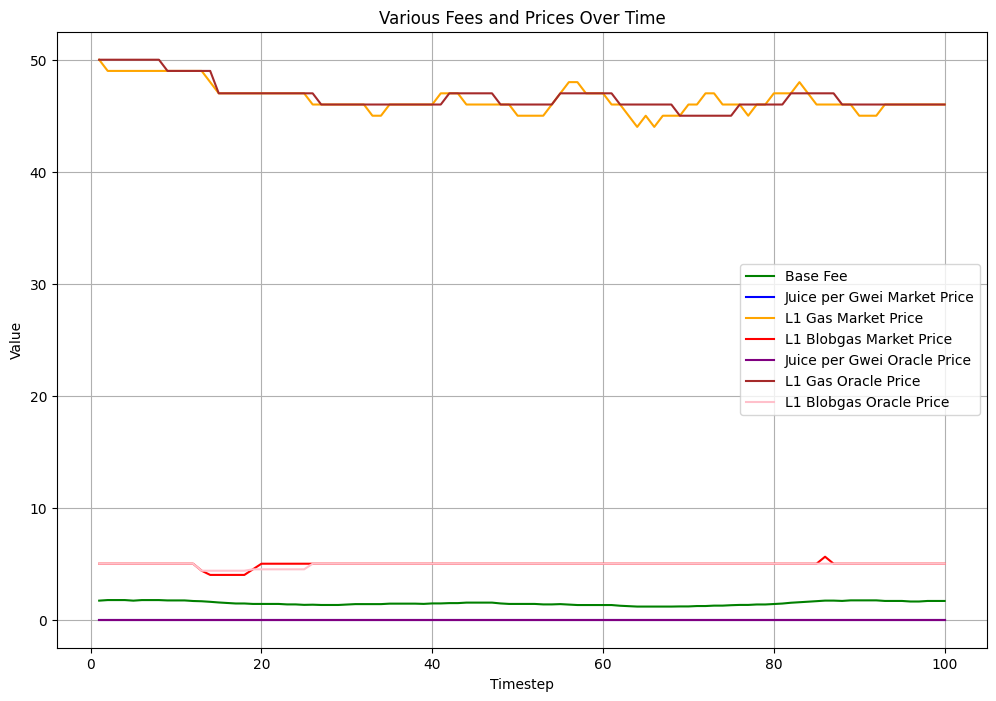

In [13]:
# 1 axis, removed congestion multiplier 

plt.figure(figsize=(12, 8))

# Plot the different variables over time (timestep)
plt.plot(sim_df['timestep'], sim_df['base_fee'], label='Base Fee', color='green')
plt.plot(sim_df['timestep'], sim_df['market_price_juice_per_gwei'], label='Juice per Gwei Market Price', color='blue')
plt.plot(sim_df['timestep'], sim_df['market_price_l1_gas'], label='L1 Gas Market Price', color='orange')
plt.plot(sim_df['timestep'], sim_df['market_price_l1_blobgas'], label='L1 Blobgas Market Price', color='red')
plt.plot(sim_df['timestep'], sim_df['oracle_price_juice_per_gwei'], label='Juice per Gwei Oracle Price', color='purple')
plt.plot(sim_df['timestep'], sim_df['oracle_price_l1_gas'], label='L1 Gas Oracle Price', color='brown')
plt.plot(sim_df['timestep'], sim_df['oracle_price_l1_blobgas'], label='L1 Blobgas Oracle Price', color='pink')
#plt.plot(sim_df['timestep'], sim_df['congestion_multiplier'], label='Congestion Multiplier', color='black')

# Title and labels
plt.title('Various Fees and Prices Over Time')
plt.xlabel('Timestep')
plt.ylabel('Value')

# Adding a legend to distinguish the lines
plt.legend()

# Display the grid
plt.grid(True)

# Show the plot
plt.show()



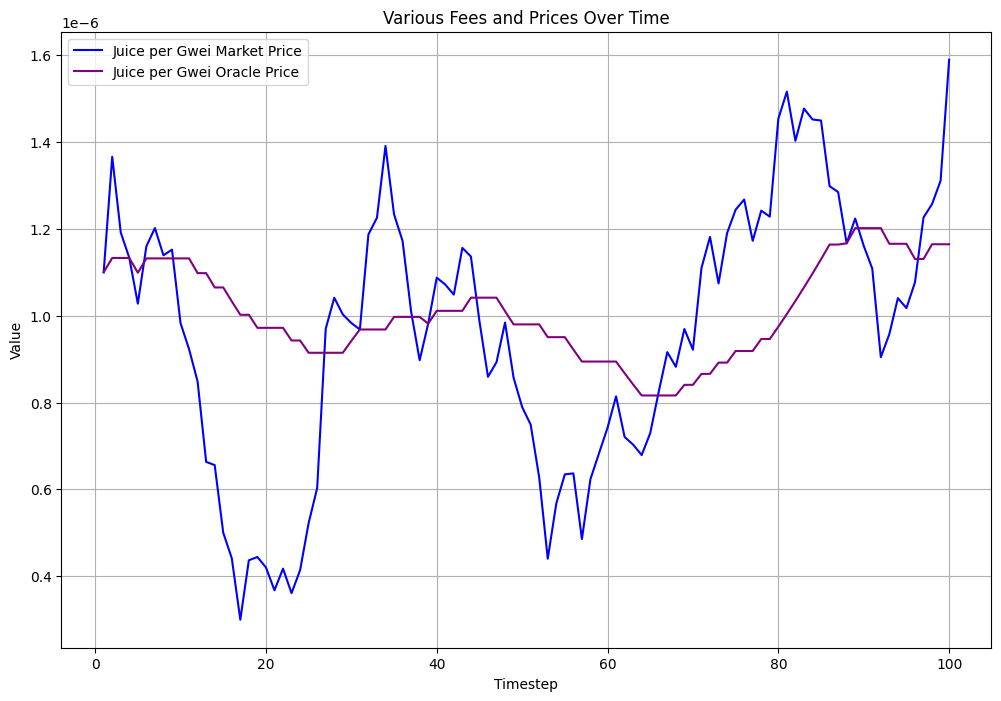

In [14]:
# Separating Juice per Gwei

plt.figure(figsize=(12, 8))
plt.plot(sim_df['timestep'], sim_df['market_price_juice_per_gwei'], label='Juice per Gwei Market Price', color='blue')
plt.plot(sim_df['timestep'], sim_df['oracle_price_juice_per_gwei'], label='Juice per Gwei Oracle Price', color='purple')

# Title and labels
plt.title('Various Fees and Prices Over Time')
plt.xlabel('Timestep')
plt.ylabel('Value')

# Adding a legend to distinguish the lines
plt.legend()

# Display the grid
plt.grid(True)

# Show the plot
plt.show()

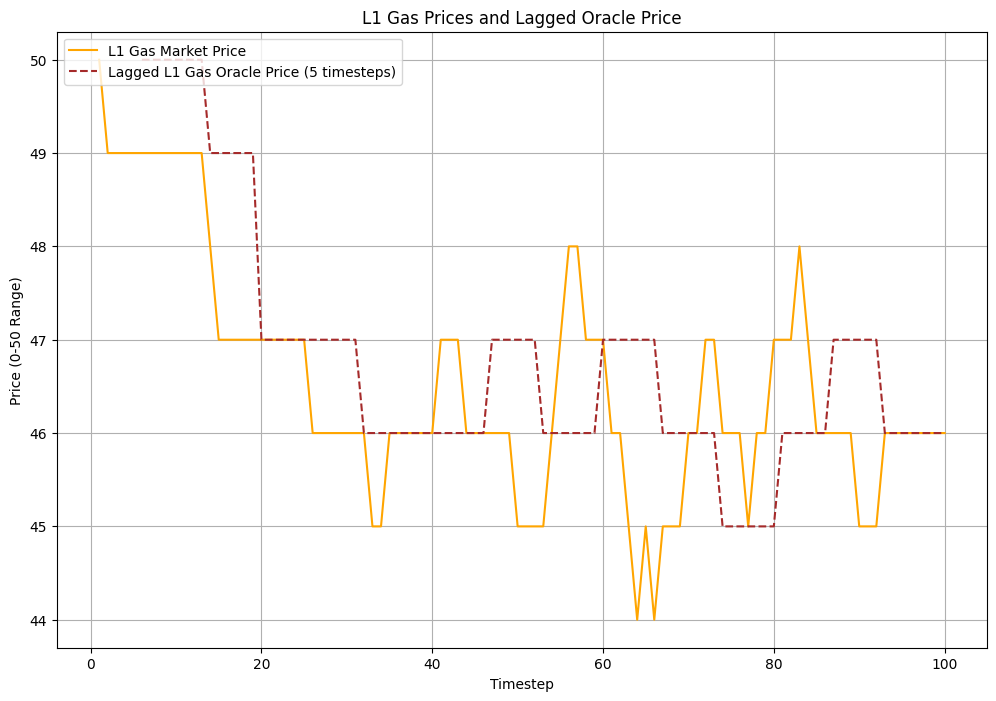

In [15]:
# Shifting Oracle from Market price

import matplotlib.pyplot as plt

# Create a figure and plot variables
fig, ax1 = plt.subplots(figsize=(12, 8))

# Plot leading variable
ax1.plot(sim_df['timestep'], sim_df['market_price_l1_gas'], label='L1 Gas Market Price', color='orange')

# Plot lagged variable (shifted by 5 timesteps)
ax1.plot(sim_df['timestep'], sim_df['oracle_price_l1_gas'].shift(5), label='Lagged L1 Gas Oracle Price (5 timesteps)', color='brown', linestyle='--')

# Set labels and title
ax1.set_xlabel('Timestep')
ax1.set_ylabel('Price (0-50 Range)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_title('L1 Gas Prices and Lagged Oracle Price')

# Add a combined legend
ax1.legend(loc='upper left')

# Display grid
ax1.grid(True)

# Show the plot
plt.show()



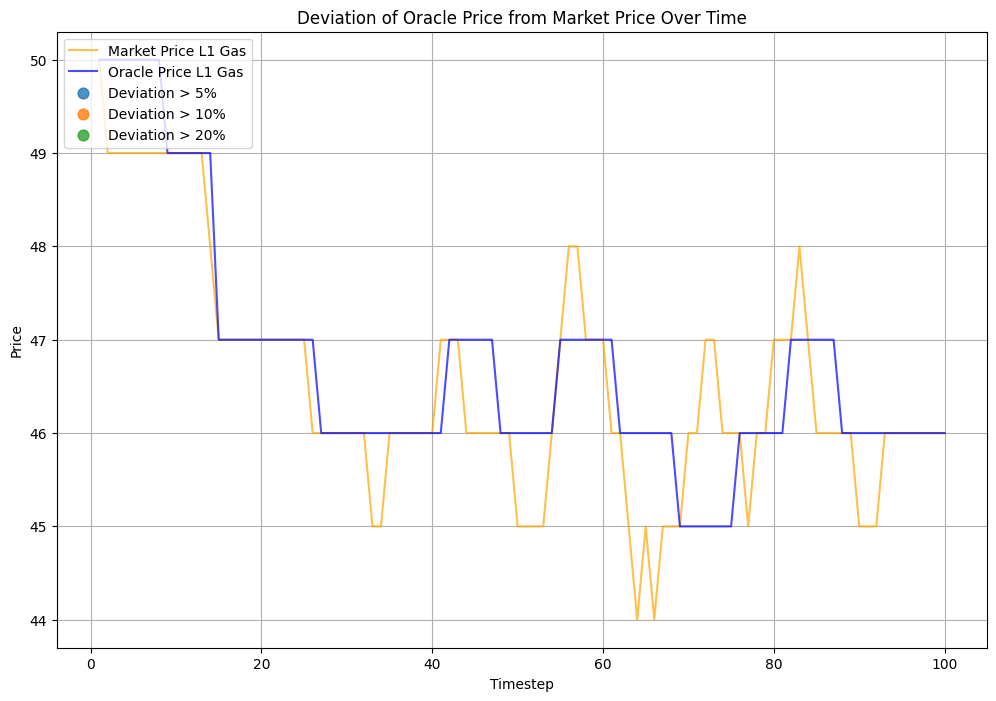

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the percentage difference between oracle and market prices
sim_df['percentage_diff'] = np.abs((sim_df['oracle_price_l1_gas'] - sim_df['market_price_l1_gas']) / sim_df['market_price_l1_gas']) * 100

# Define thresholds for deviations
#thresholds = [1, 2, 5, 10, 20]
thresholds = [5, 10, 20]

# Create a plot for each threshold
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the market price and oracle price for reference
ax.plot(sim_df['timestep'], sim_df['market_price_l1_gas'], label='Market Price L1 Gas', color='orange', alpha=0.7)
ax.plot(sim_df['timestep'], sim_df['oracle_price_l1_gas'], label='Oracle Price L1 Gas', color='blue', alpha=0.7)

# Highlight the timesteps where the deviation exceeds each threshold
for threshold in thresholds:
    # Identify the timesteps where the percentage difference exceeds the threshold
    above_threshold = sim_df[sim_df['percentage_diff'] >= threshold]
    
    # Plot vertical lines at the timesteps where the deviation exceeds the threshold
    ax.scatter(above_threshold['timestep'], above_threshold['oracle_price_l1_gas'], label=f'Deviation > {threshold}%', marker='o', s=60, alpha=0.8)
    
# Set labels, title, and legend
ax.set_xlabel('Timestep')
ax.set_ylabel('Price', color='black')
ax.tick_params(axis='y', labelcolor='black')
ax.set_title('Deviation of Oracle Price from Market Price Over Time')

# Display grid
ax.grid(True)

# Add a legend
ax.legend(loc='upper left')

# Show the plot
plt.show()


## Archive / Trial 

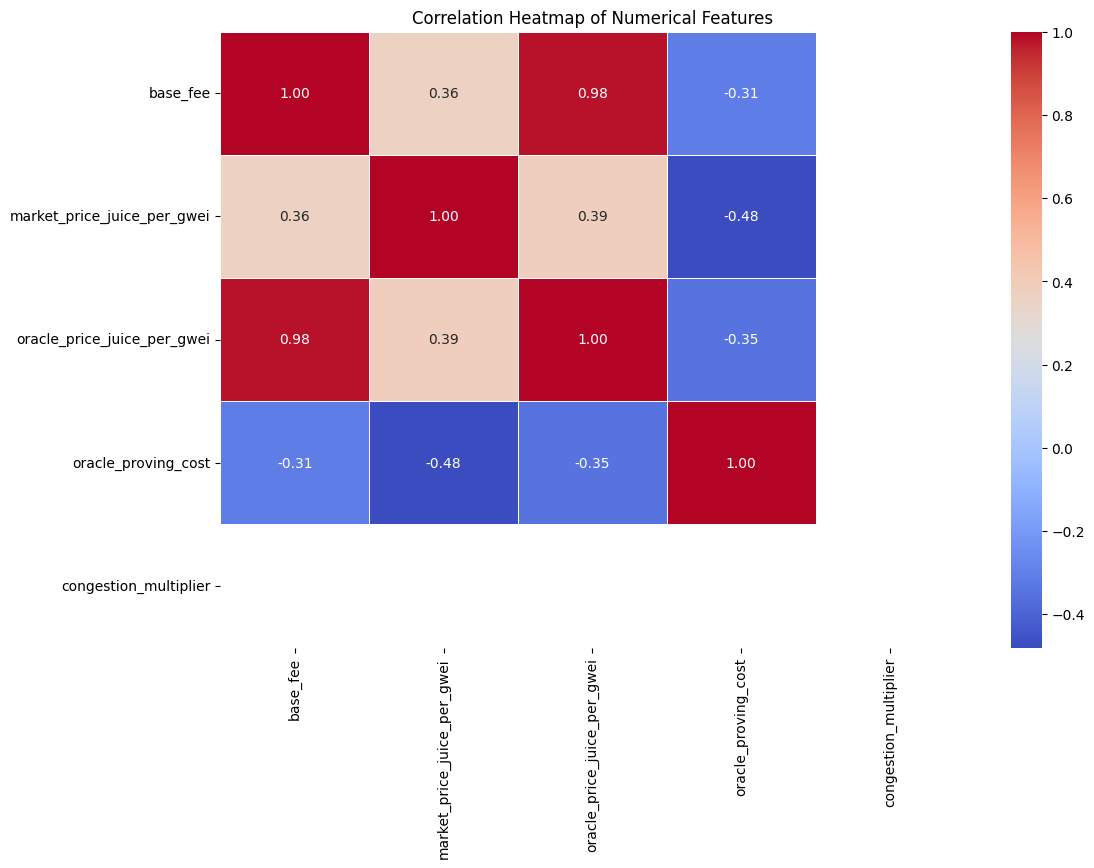

In [17]:
# Select numerical columns of interest for correlation analysis
corr_columns = [
    'base_fee', 
    'market_price_juice_per_gwei', 'oracle_price_juice_per_gwei', 'oracle_proving_cost',
    'congestion_multiplier'
]
corr_matrix = sim_df[corr_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

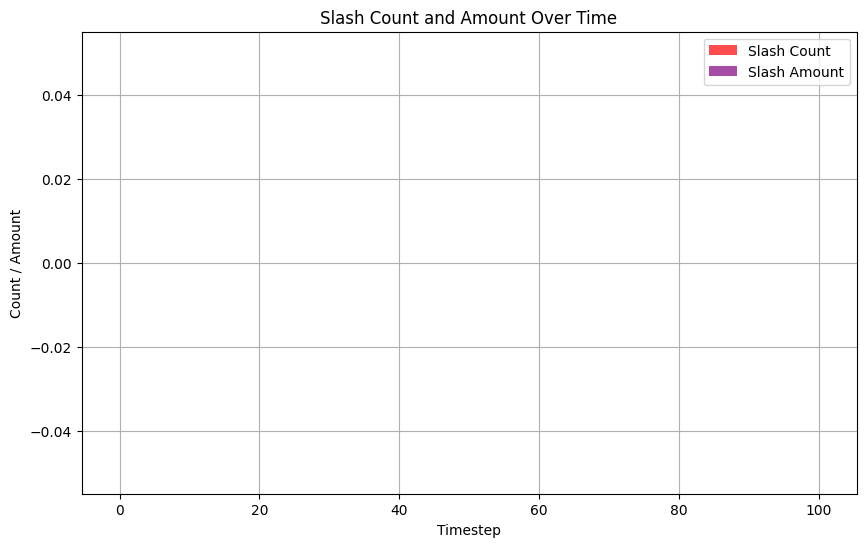

In [18]:
plt.figure(figsize=(10, 6))
plt.bar(sim_df['timestep'], sim_df['slash_count'], label='Slash Count', alpha=0.7, color='red')
plt.bar(sim_df['timestep'], sim_df['slash_amount'], label='Slash Amount', alpha=0.7, color='purple')
plt.title('Slash Count and Amount Over Time')
plt.xlabel('Timestep')
plt.ylabel('Count / Amount')
plt.legend()
plt.grid(True)
plt.show()

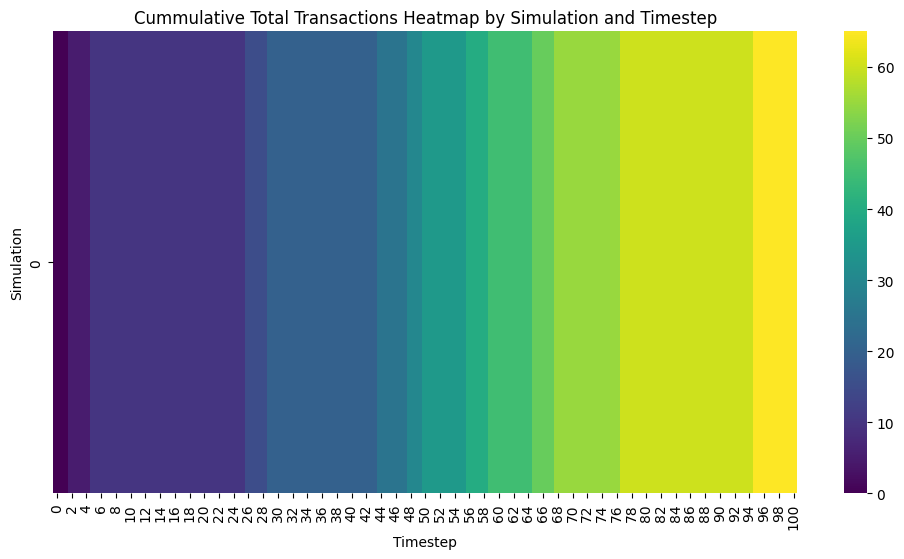

In [19]:
heatmap_data = sim_df.pivot_table(values='cumm_total_tx', index='simulation', columns='timestep', aggfunc='sum')

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='viridis', annot=False)
plt.title('Cummulative Total Transactions Heatmap by Simulation and Timestep')
plt.xlabel('Timestep')
plt.ylabel('Simulation')
plt.show()